In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv('matches.csv')
print("Initial Data Shape:", df.shape)

Initial Data Shape: (1095, 20)


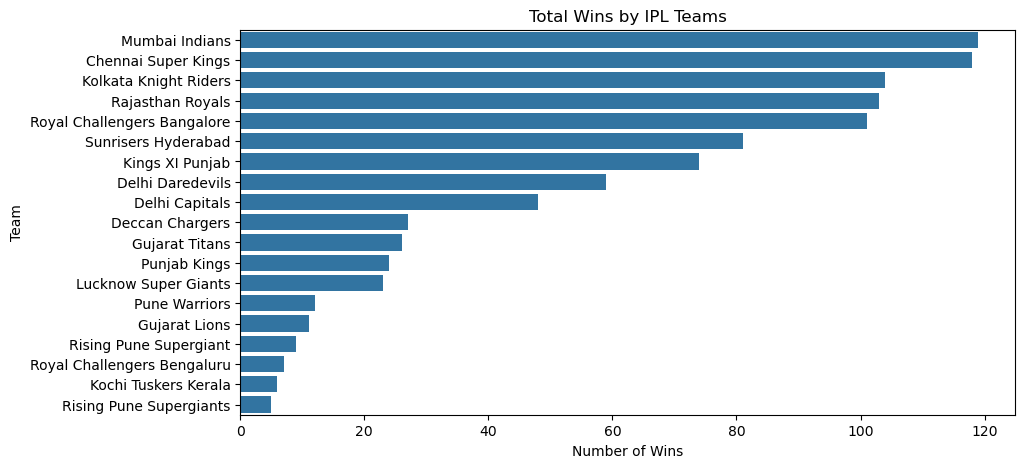

In [5]:
df.drop_duplicates(inplace=True)

columns_to_keep = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']
df = df[columns_to_keep]

df.dropna(subset=['winner'], inplace=True)

plt.figure(figsize=(10, 5))
sns.countplot(y='winner', data=df, order=df['winner'].value_counts().index)
plt.title('Total Wins by IPL Teams')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.show()

encoder = LabelEncoder()
for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

X = df.drop('winner', axis=1)
y = df['winner']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [7]:
print("\n--- Model Evaluation Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")


--- Model Evaluation Results ---
Accuracy:  0.4688
Precision: 0.4831
Recall:    0.4688
F1-Score:  0.4655


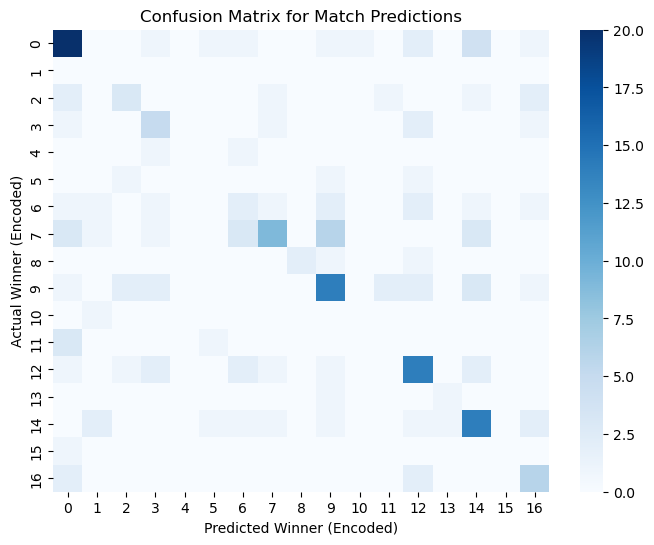

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix for Match Predictions')
plt.ylabel('Actual Winner (Encoded)')
plt.xlabel('Predicted Winner (Encoded)')
plt.show()